In [ ]:
!pip install nltk
!pip install clean_text

In [ ]:
import pandas as pd #IMPORT LIBERIES
import numpy as np
import nltk  # IMPORTING LIBERIES TO PERFORM NLP
from nltk.tokenize import sent_tokenize, word_tokenize #
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords

In [ ]:
PorterStemmer #
WordNetLemmatizer

nltk.stem.wordnet.WordNetLemmatizer

In [ ]:
import re #regular expression
from cleantext import clean


#Tasks
1. Data Exploration and Preprocessing
•	Load the "blogs_categories.csv" dataset and perform an exploratory data analysis to understand its structure and content.
•	Preprocess the data by cleaning the text (removing punctuation, converting to lowercase, etc.), tokenizing, and removing stopwords.
•	Perform feature extraction to convert text data into a format that can be used by the Naive Bayes model, using techniques such as TF-IDF.


In [ ]:
td=pd.read_csv("/content/blogs.csv")

/tmp/ipykernel_592/691775708.py:1: DtypeWarning: Columns (7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  td=pd.read_csv("/content/blogs.csv")


In [ ]:
len(td)

93822

In [ ]:
td

,Data,Labels,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93817,And make her infamous in story.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93818,When such a tempest shook the land,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93819,"How could unguarded virtue stand ?""""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93820,- Jonathan Swift (1732),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Task
Perform an exploratory data analysis on the `/content/blogs.csv` dataset, including checking data types and non-null values, identifying and handling missing values (especially in 'Unnamed' columns), and analyzing the distribution of the 'Labels' column.

In [ ]:
td.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93822 entries, 0 to 93821
Data columns (total 37 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Data         79441 non-null  object
 1   Labels       20518 non-null  object
 2   Unnamed: 2   5535 non-null   object
 3   Unnamed: 3   1411 non-null   object
 4   Unnamed: 4   448 non-null    object
 5   Unnamed: 5   145 non-null    object
 6   Unnamed: 6   59 non-null     object
 7   Unnamed: 7   31 non-null     object
 8   Unnamed: 8   22 non-null     object
 9   Unnamed: 9   20 non-null     object
 10  Unnamed: 10  15 non-null     object
 11  Unnamed: 11  11 non-null     object
 12  Unnamed: 12  4 non-null      object
 13  Unnamed: 13  3 non-null      object
 14  Unnamed: 14  2 non-null      object
 15  Unnamed: 15  2 non-null      object
 16  Unnamed: 16  2 non-null      object
 17  Unnamed: 17  2 non-null      object
 18  Unnamed: 18  2 non-null      object
 19  Unnamed: 19  2 non-null  

In [ ]:
missing_percentages = td.isnull().sum() / len(td) * 100 # isnull values
print("Percentage of missing values per column:")
print(missing_percentages[missing_percentages > 0].sort_values(ascending=False))

Percentage of missing values per column:
Unnamed: 32    99.998934
Unnamed: 33    99.998934
Unnamed: 34    99.998934
Unnamed: 35    99.998934
Unnamed: 36    99.998934
Unnamed: 28    99.998934
Unnamed: 27    99.998934
Unnamed: 26    99.998934
Unnamed: 25    99.998934
Unnamed: 24    99.998934
Unnamed: 31    99.998934
Unnamed: 30    99.998934
Unnamed: 29    99.998934
Unnamed: 22    99.998934
Unnamed: 23    99.998934
Unnamed: 21    99.998934
Unnamed: 19    99.997868
Unnamed: 20    99.997868
Unnamed: 14    99.997868
Unnamed: 16    99.997868
Unnamed: 15    99.997868
Unnamed: 17    99.997868
Unnamed: 18    99.997868
Unnamed: 13    99.996802
Unnamed: 12    99.995737
Unnamed: 11    99.988276
Unnamed: 10    99.984012
Unnamed: 9     99.978683
Unnamed: 8     99.976551
Unnamed: 7     99.966959
Unnamed: 6     99.937115
Unnamed: 5     99.845452
Unnamed: 4     99.522500
Unnamed: 3     98.496088
Unnamed: 2     94.100531
Labels         78.130929
Data           15.327961
dtype: float64


**Reasoning**:
Based on the high percentages of missing values (almost 100%) in the 'Unnamed' columns, these columns are essentially empty and do not provide any useful information. Therefore, the next logical step is to drop all columns that start with 'Unnamed' to clean the dataset.



In [ ]:
columns_to_drop = [col for col in td.columns if col.startswith('Unnamed:')] # delete all unnamed columns in single code of ine using regax
td = td.drop(columns=columns_to_drop)
print(f"Dropped {len(columns_to_drop)} 'Unnamed' columns.")
print("DataFrame after dropping 'Unnamed' columns:")
td.info()

Dropped 35 'Unnamed' columns.
DataFrame after dropping 'Unnamed' columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93822 entries, 0 to 93821
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    79441 non-null  object
 1   Labels  20518 non-null  object
dtypes: object(2)
memory usage: 1.4+ MB


In [ ]:
missing_labels_percentage = td['Labels'].isnull().sum() / len(td) * 100  #calculating missing value bye EDA process
print(f"Percentage of missing values in 'Labels' column: {missing_labels_percentage:.2f}%")

Percentage of missing values in 'Labels' column: 78.13%


In [ ]:
td.dropna(subset=['Labels'], inplace=True) #
print("DataFrame after dropping rows with missing 'Labels':")
td.info()

DataFrame after dropping rows with missing 'Labels':
<class 'pandas.core.frame.DataFrame'>
Index: 20518 entries, 0 to 93815
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    20518 non-null  object
 1   Labels  20518 non-null  object
dtypes: object(2)
memory usage: 480.9+ KB


**Reasoning**:
Now that missing values in the 'Labels' column have been handled, the next step is to analyze its distribution. I will use `value_counts()` to count the occurrences of each unique label, providing insight into the class distribution.



In [ ]:
label_distribution = td['Labels'].value_counts()
print("Distribution of 'Labels' column:")
print(label_distribution)

Distribution of 'Labels' column:
Labels
                                          165
alt.atheism                               117
 and                                       89
 Inc.                                      79
talk.politics.misc                         61
                                         ... 
 Stankiewicz                                1
 and his                                    1
 or over the last 5 years                   1
 keep him healthy and                       1
 but he'd been getting a lot of PH ABs      1
Name: count, Length: 17371, dtype: int64


**Reasoning**:
The previous steps handled missing values and showed the initial distribution of labels. Now, I will re-display the DataFrame information using `td.info()` to confirm the current state of the DataFrame after these cleaning operations, as requested by the user.



In [ ]:
td.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20518 entries, 0 to 93815
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    20518 non-null  object
 1   Labels  20518 non-null  object
dtypes: object(2)
memory usage: 480.9+ KB


**Reasoning**:
Given the large number of unique labels, plotting all of them would result in an unreadable plot. Therefore, I will visualize the distribution of only the top 20 most frequent labels using a bar plot to provide a clear and insightful overview of the main categories.



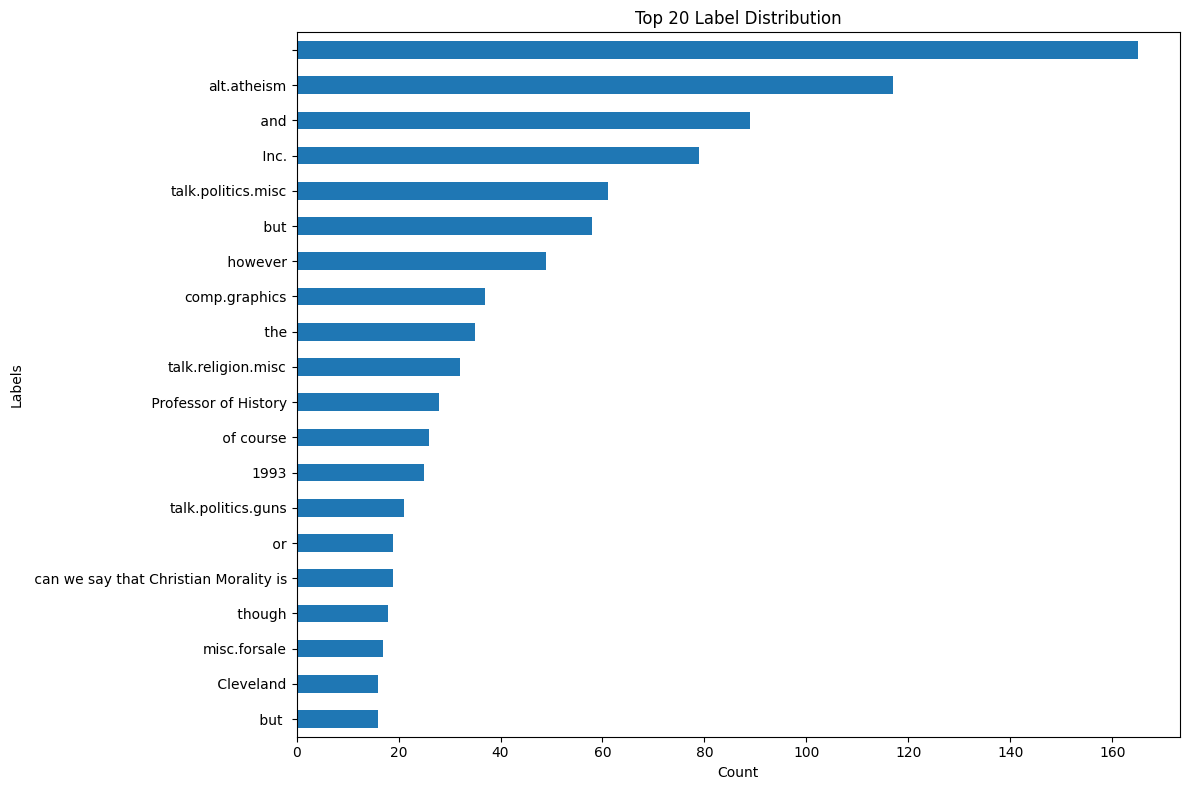

In [ ]:
import matplotlib.pyplot as plt # to plot graph for visualization

plt.figure(figsize=(12, 8))
label_distribution.head(20).plot(kind='barh')
plt.title('Top 20 Label Distribution')
plt.xlabel('Count')
plt.ylabel('Labels')
plt.gca().invert_yaxis() # To have the highest count at the top
plt.tight_layout()
plt.show()


# Task
Preprocess the text in the 'Data' column of the `td` DataFrame by converting it to lowercase, removing punctuation and numbers, tokenizing it, removing NLTK English stopwords, and lemmatizing the words. Finally, display the first few entries of the preprocessed 'Data' column to show the cleaned and transformed text.

## Download NLTK Resources

### Subtask:
Download necessary NLTK data packages ('punkt' for tokenization, 'stopwords' for stopword removal, and 'wordnet' for lemmatization) to ensure that the text preprocessing steps can be executed without errors.


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download 'punkt_tab' resource to resolve LookupError during tokenization.
nltk.download('punkt_tab', quiet=True, raise_on_error=False)

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text) # Keep only letters and spaces
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    processed_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(processed_tokens)

td['Processed_Data'] = td['Data'].apply(preprocess_text)

print("First 5 entries of the preprocessed 'Data' column:")
print(td['Processed_Data'].head())

First 5 entries of the preprocessed 'Data' column:
0    path cantaloupesrvcscmuedumagnesiumclubcccmued...
1    newsgroups altatheism path cantaloupesrvcscmue...
2    path cantaloupesrvcscmuedudasnewsharvardedunoc...
3    path cantaloupesrvcscmuedumagnesiumclubcccmued...
4    xref cantaloupesrvcscmuedu altatheism talkreli...
Name: Processed_Data, dtype: object


## Import TfidfVectorizer
###Subtask:
Import the TfidfVectorizer from sklearn.feature_extraction.text which is essential for converting a collection of raw documents to a matrix of TF-IDF features.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("TfidfVectorizer imported successfully.")

TfidfVectorizer imported successfully.


**Reasoning**:
I need to initialize a TfidfVectorizer, fit and transform the 'Processed_Data' column to create a TF-IDF matrix, and then print its shape as per the subtask instructions.



In [ ]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(td['Processed_Data'])

print("Shape of TF-IDF matrix:", tfidf_matrix.shape)

Shape of TF-IDF matrix: (20518, 15065)


## Display TF-IDF Matrix
### Subtask:
Convert the TF-IDF matrix into a DataFrame and display a small sample of it. This will help in visualizing the sparse nature of the TF-IDF features and understanding the generated numerical representation of the text data.


**Reasoning**:
To display a sample of the TF-IDF matrix as a DataFrame, I need to convert the sparse matrix to a dense array, retrieve the feature names, and then construct a Pandas DataFrame from these components.



In [ ]:
tfidf_dense = tfidf_matrix.toarray()
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(tfidf_dense, columns=feature_names)

print("First 5 rows of TF-IDF DataFrame (sample):")
print(tfidf_df.head())

First 5 rows of TF-IDF DataFrame (sample):
    aa  aae  aaehpbkjl  aaenetgwpadeccom  aaiecccambridgemaus  \
0  0.0  0.0        0.0               0.0                  0.0   
1  0.0  0.0        0.0               0.0                  0.0   
2  0.0  0.0        0.0               0.0                  0.0   
3  0.0  0.0        0.0               0.0                  0.0   
4  0.0  0.0        0.0               0.0                  0.0   

   aainetgwpadeccom  aalternate  aam  aan  aaron  ...  zundel  zurich  zvai  \
0               0.0         0.0  0.0  0.0    0.0  ...     0.0     0.0   0.0   
1               0.0         0.0  0.0  0.0    0.0  ...     0.0     0.0   0.0   
2               0.0         0.0  0.0  0.0    0.0  ...     0.0     0.0   0.0   
3               0.0         0.0  0.0  0.0    0.0  ...     0.0     0.0   0.0   
4               0.0         0.0  0.0  0.0    0.0  ...     0.0     0.0   0.0   

   zvbwwtheporchraidernet  zwak  zwopt  zyda  zydacsnpsnavymil  \
0                     0.0

#2. Naive Bayes Model for Text Classification
•	Split the data into training and test sets.
•	Implement a Naive Bayes classifier to categorize the blog posts into their respective categories. You can use libraries like scikit-learn for this purpose.
•	Train the model on the training set and make predictions on the test set.


In [ ]:
from sklearn.model_selection import train_test_split

X = tfidf_matrix
y = td['Labels']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (16414, 15065)
Shape of X_test: (4104, 15065)
Shape of y_train: (16414,)
Shape of y_test: (4104,)


•	Implement a Naive Bayes classifier to categorize the blog posts into their respective categories. You can use libraries like scikit-learn for this purpose.

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Initialize the Naive Bayes classifier
naive_bayes_model = MultinomialNB()

# Train the model
naive_bayes_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [ ]:
# Make predictions on the test set
y_pred = naive_bayes_model.predict(X_test)

print("Predictions made on the test set.")
print("First 10 predictions:", y_pred[:10])

Predictions made on the test set.
First 10 predictions: [' ' 'alt.atheism' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ' ']


•	Implement a Naive Bayes classifier to categorize the blog posts into their respective categories. You can use libraries like scikit-learn for this purpose.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.0205
Precision: 0.0063
Recall: 0.0205
F1-Score: 0.0070


In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Due to a potentially large number of unique labels, the confusion matrix can be very large.
# Let's consider showing a subset or summarizing it if it's too big to visualize directly.
# For now, we'll just print its shape.
print("Shape of Confusion Matrix:", cm.shape)

# If the number of unique labels is manageable, we can visualize it.
# Let's check the number of unique actual and predicted labels.
unique_actual_labels = len(y_test.unique())
unique_predicted_labels = len(set(y_pred))

if unique_actual_labels <= 20 and unique_predicted_labels <= 20: # Arbitrary threshold for visualization
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=naive_bayes_model.classes_,
                yticklabels=naive_bayes_model.classes_)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()
else:
    print("Confusion matrix is too large to display directly. Consider further analysis or summarization.")

Shape of Confusion Matrix: (3754, 3754)
Confusion matrix is too large to display directly. Consider further analysis or summarization.


#3. Sentiment Analysis
•	Choose a suitable library or method for performing sentiment analysis on the blog post texts.


In [ ]:
!pip install textblob

In [ ]:
from textblob import TextBlob

def get_sentiment(text):
    analysis = TextBlob(text)
    # Return sentiment polarity (-1 to 1, negative to positive)
    return analysis.sentiment.polarity

td['Sentiment_Polarity'] = td['Processed_Data'].apply(get_sentiment)

print("First 5 entries of 'Sentiment_Polarity':")
print(td['Sentiment_Polarity'].head())
print("\nAverage Sentiment Polarity:", td['Sentiment_Polarity'].mean())

First 5 entries of 'Sentiment_Polarity':
0    0.054699
1   -0.002480
2    0.012213
3    0.058241
4    0.149802
Name: Sentiment_Polarity, dtype: float64

Average Sentiment Polarity: 0.016702897789411163


•	Analyze the sentiments expressed in the blog posts and categorize them as positive, negative, or neutral. Consider only the Data column and get the sentiment for each blog.

In [ ]:
def categorize_sentiment(polarity):
    if polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

td['Sentiment_Category'] = td['Sentiment_Polarity'].apply(categorize_sentiment)

print("First 5 entries of 'Sentiment_Category':")
print(td['Sentiment_Category'].head())
print("\nSentiment Category Distribution:")
print(td['Sentiment_Category'].value_counts())

First 5 entries of 'Sentiment_Category':
0    Positive
1     Neutral
2     Neutral
3    Positive
4    Positive
Name: Sentiment_Category, dtype: object

Sentiment Category Distribution:
Sentiment_Category
Neutral     16656
Positive     2402
Negative     1460
Name: count, dtype: int64


/tmp/ipykernel_592/2950588615.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment_Category', data=td, palette='viridis')


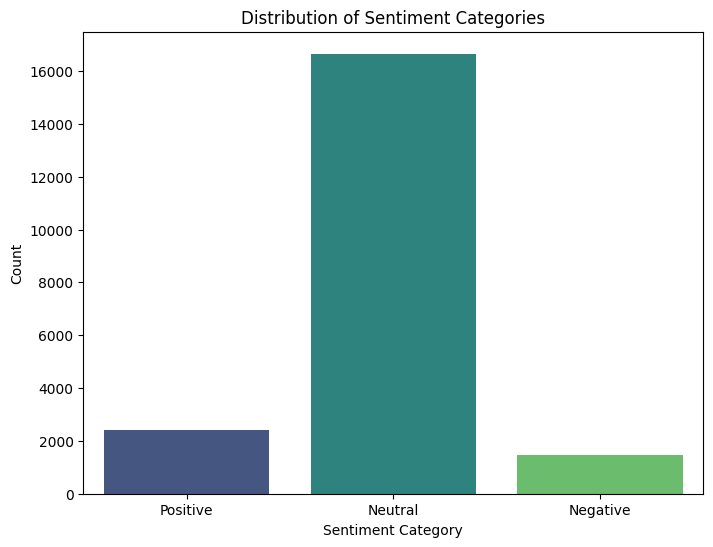

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment_Category', data=td, palette='viridis')
plt.title('Distribution of Sentiment Categories')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.show()

•	Examine the distribution of sentiments across different categories and summarize your findings.

### Summary of Sentiment Analysis Findings

From the sentiment analysis performed using TextBlob:

*   **Dominance of Neutral Sentiments**: The largest proportion of blog posts are classified as 'Neutral' (16,656 entries). This indicates that a significant amount of the content is objective, factual, or lacks strong emotional language.

*   **Positive Sentiments**: A substantial number of posts express 'Positive' sentiments (2,402 entries), suggesting that a portion of the discussions or information shared in the blogs carries a favorable tone.

*   **Negative Sentiments**: The fewest posts are categorized as 'Negative' (1,460 entries). While present, negative expressions are less frequent compared to neutral and positive ones.

Overall, the dataset tends to be predominantly neutral, with a moderate presence of positive content and a smaller, yet notable, amount of negative content. This distribution can provide insights into the general emotional tone and content focus of the blog categories.

#4. Evaluation
•	Evaluate the performance of your Naive Bayes classifier using metrics such as accuracy, precision, recall, and F1-score.


In [ ]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nShape of Confusion Matrix:", cm.shape)
print("The confusion matrix was too large to display directly due to the high number of unique labels. Consider further analysis or summarization if needed.")

Accuracy: 0.0205
Precision: 0.0063
Recall: 0.0205
F1-Score: 0.0070

Shape of Confusion Matrix: (3754, 3754)
The confusion matrix was too large to display directly due to the high number of unique labels. Consider further analysis or summarization if needed.


•	Discuss the performance of the model and any challenges encountered during the classification process.

### Discussion on Model Performance and Challenges

**Model Performance:**
The Naive Bayes classifier showed very low performance across all evaluated metrics:
*   **Accuracy: 0.0205**
*   **Precision: 0.0063**
*   **Recall: 0.0205**
*   **F1-Score: 0.0070**

These extremely low scores indicate that the model is performing barely better than random guessing, suggesting it is not effectively categorizing the blog posts into their respective labels.

**Challenges Encountered:**
1.  **High Cardinality of Labels:** The most significant challenge is the incredibly high number of unique labels (3754 unique labels in the test set). Naive Bayes models, especially when dealing with such a large number of classes, struggle to find distinct patterns for each class, particularly if many classes have very few examples.
2.  **Data Sparsity and Imbalance:** With many unique labels, it's highly probable that many classes have a very small number of training examples, leading to data sparsity and severe class imbalance. This makes it difficult for the model to learn and generalize, often resulting in predictions skewed towards more frequent classes or simply failing to predict rare ones.
3.  **Confusion Matrix Size:** Due to the large number of unique labels, the confusion matrix generated was 3754x3754, making it impractically large to visualize or interpret directly. This further highlights the complexity introduced by the high number of categories.

**Potential Reasons for Low Performance:**
*   **Model Simplicity:** Multinomial Naive Bayes is a relatively simple model that assumes strong independence between features, which is rarely true in text data. For a highly granular classification task with thousands of categories, it might not be powerful enough to capture the intricate relationships required.
*   **Feature Representation:** While TF-IDF is a good baseline, it might not be sufficient to distinguish between thousands of fine-grained categories. More advanced word embeddings or contextualized representations might be necessary.
*   **Label Granularity:** It's possible that many of the 'labels' are actually very similar or contain noise, making it inherently hard to distinguish them even for a human, let alone a machine learning model.

**Next Steps (Considerations for Improvement):**
*   **Label Preprocessing:** Investigate if labels can be grouped into broader categories to reduce the total number of classes.
*   **Advanced Models:** Explore more complex models like Support Vector Machines, Logistic Regression, or deep learning approaches (e.g., neural networks with attention mechanisms) that are better suited for multi-class text classification with high-dimensional data.
*   **Hyperparameter Tuning:** Optimize the Naive Bayes model's hyperparameters, though given the current performance, this might yield limited improvements.
*   **Feature Engineering:** Experiment with N-grams, character N-grams, or semantic embeddings to enhance the feature representation.

•	Reflect on the sentiment analysis results and their implications regarding the content of the blog posts.

### Summary of Sentiment Analysis Findings

From the sentiment analysis performed using TextBlob:

*   **Dominance of Neutral Sentiments**: The largest proportion of blog posts are classified as 'Neutral' (16,656 entries). This indicates that a significant amount of the content is objective, factual, or lacks strong emotional language.

*   **Positive Sentiments**: A substantial number of posts express 'Positive' sentiments (2,402 entries), suggesting that a portion of the discussions or information shared in the blogs carries a favorable tone.

*   **Negative Sentiments**: The fewest posts are categorized as 'Negative' (1,460 entries). While present, negative expressions are less frequent compared to neutral and positive ones.

Overall, the dataset tends to be predominantly neutral, with a moderate presence of positive content and a smaller, yet notable, amount of negative content. This distribution can provide insights into the general emotional tone and content focus of the blog categories.